In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import os

# Assumption: The preprocessed dataset already has three contrast-adjusted channels and is stored as 3-channel images.

# Basic data transformation (resize and normalize only)
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Adjust dimensions if needed to reduce memory load
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalizing 3 channels equally
])

# Load the preprocessed 3-channel contrast dataset
data_dir = 'processed_dataset'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split dataset into training, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders with a modest batch size
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}

# Get class names and count
class_names = full_dataset.classes
num_classes = len(class_names)
print("Number of classes:", num_classes)

# Model definition for 3-channel input
class SimpleResNet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleResNet, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        
        # Modify the first convolution layer to accept 3 channels
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        
        # Replace the fully connected layer for classification
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# Initialize model, optimizer, and criterion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleResNet(num_classes=num_classes).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()



Number of classes: 491


In [13]:

# Training function with early stopping
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5):
    best_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    # Calculate accuracy
                    _, preds = torch.max(outputs, 1)
                    running_corrects += torch.sum(preds == labels)
                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Early stopping check for validation accuracy
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    epochs_no_improve = 0  # Reset counter if accuracy improves
                    torch.save(model.state_dict(), 'simple_resnet_best.pth')  # Save the best model
                    print("Model improved and saved.")
                else:
                    epochs_no_improve += 1  # Increment counter if no improvement

                if epochs_no_improve >= patience:
                    print("Early stopping triggered.")
                    model.load_state_dict(best_model_wts)
                    return model  # Return the best model early

    # Load the best model weights before returning
    model.load_state_dict(best_model_wts)
    return model

# Train the model with early stopping
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5)


Epoch 1/25
----------
train Loss: 5.4265 Acc: 0.1024
val Loss: 4.1739 Acc: 0.2455
Model improved and saved.
Epoch 2/25
----------
train Loss: 3.5316 Acc: 0.4070
val Loss: 2.6578 Acc: 0.5421
Model improved and saved.
Epoch 3/25
----------
train Loss: 2.0553 Acc: 0.6989
val Loss: 1.3070 Acc: 0.7909
Model improved and saved.
Epoch 4/25
----------
train Loss: 1.0461 Acc: 0.8910
val Loss: 0.6736 Acc: 0.8987
Model improved and saved.
Epoch 5/25
----------
train Loss: 0.5003 Acc: 0.9672
val Loss: 0.3337 Acc: 0.9522
Model improved and saved.
Epoch 6/25
----------
train Loss: 0.2463 Acc: 0.9939
val Loss: 0.2138 Acc: 0.9660
Model improved and saved.
Epoch 7/25
----------
train Loss: 0.1356 Acc: 0.9995
val Loss: 0.1812 Acc: 0.9700
Model improved and saved.
Epoch 8/25
----------
train Loss: 0.0892 Acc: 1.0000
val Loss: 0.1449 Acc: 0.9749
Model improved and saved.
Epoch 9/25
----------
train Loss: 0.0658 Acc: 1.0000
val Loss: 0.1427 Acc: 0.9724
Epoch 10/25
----------
train Loss: 0.0527 Acc: 1.0000


In [14]:
# Testing function
def test_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')

# Test the model
test_model(model, test_loader, criterion)

Test Loss: 0.1101, Test Accuracy: 97.73%


C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_2616\566142669.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('simple_resnet_best.pth',

Label: 10092


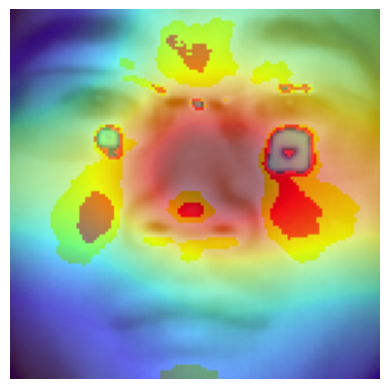

Label: 10274


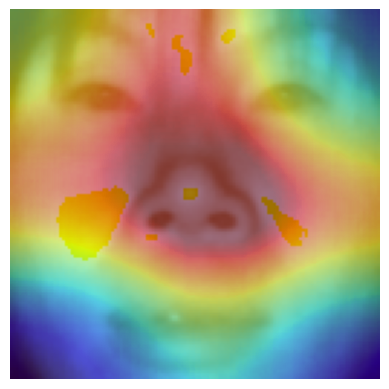

Label: 10145


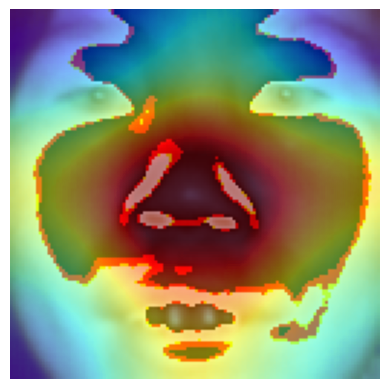

Label: 10122


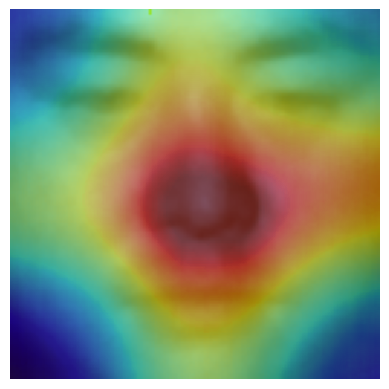

Label: 00110


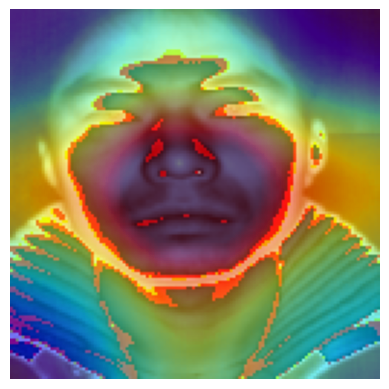

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os

# Define the model class for SimpleResNet (ensure it matches your saved model architecture)
class SimpleResNet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleResNet, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        
        # Modify the first convolution layer to accept 3 channels
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        
        # Replace the fully connected layer for classification
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.backbone(x)

# Load the saved model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 491  # Replace with your actual number of classes
model = SimpleResNet(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('simple_resnet_best.pth', map_location=device))
model.eval()

# Define the Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def __call__(self, input_tensor, class_idx=None):
        input_tensor = input_tensor.to(device)
        
        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output)
        
        # Zero gradients and perform backward pass
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()
        
        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]
        
        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Function to preprocess an image for model input
def preprocess_image(image):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    return transform(image).unsqueeze(0)

# Function to overlay heatmap on an image
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

# Instantiate the Grad-CAM object with the loaded model
target_layer = model.backbone.layer4[-1]  # Last layer in ResNet50's layer4 block
grad_cam = GradCAM(model, target_layer)

# Visualize Grad-CAM for a few images from the test set
for i in range(5):  # Display Grad-CAM for 5 images in the test set
    image, label = test_dataset[i]
    img_pil = transforms.ToPILImage()(image)  # Convert tensor to PIL image for display
    
    input_tensor = image.unsqueeze(0).to(device)  # Add batch dimension
    heatmap = grad_cam(input_tensor)

    print(f"Label: {class_names[label]}")
    overlay_heatmap(img_pil, heatmap)

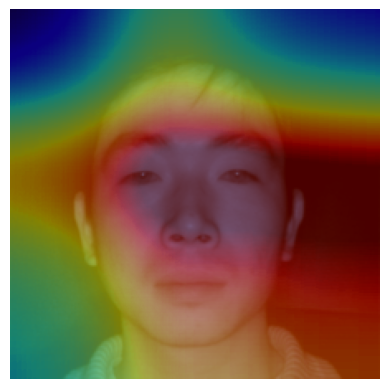

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image, ImageEnhance
import os

# Step 1: Preprocess a single image to create a 3-channel contrast-adjusted image
def preprocess_single_image(image_path):
    transform_resized = transforms.Resize((224, 224))  # Adjust size for model input

    # Open the NIR image in grayscale
    image = Image.open(image_path).convert("L")

    # Apply contrast adjustments
    enhancer = ImageEnhance.Contrast(image)
    low_contrast = enhancer.enhance(0.5)
    mid_contrast = enhancer.enhance(1.0)  # Original contrast
    high_contrast = enhancer.enhance(1.5)

    # Merge into 3 channels
    combined_image = Image.merge("RGB", (low_contrast, mid_contrast, high_contrast))
    combined_image = transform_resized(combined_image)  # Resize for model input

    return combined_image

# Function to preprocess the image for model input
def preprocess_image_for_model(combined_image):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Match model's expected input size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    # Transform the 3-channel image
    input_tensor = transform(combined_image).unsqueeze(0)  # Add batch dimension
    return input_tensor

# Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)
        
        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output)
        
        # Zero gradients and perform backward pass
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()
        
        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]
        
        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Function to overlay heatmap on an image
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

# Instantiate the Grad-CAM object
target_layer = model.backbone.layer4[-1]  # Last layer in ResNet50's layer4 block
grad_cam = GradCAM(model, target_layer)

# Preprocess the input image
image_path = "001.bmp"  # Path to the NIR image
combined_image = preprocess_single_image(image_path)  # Generate 3-channel contrast image
input_tensor = preprocess_image_for_model(combined_image).to(device)  # Prepare for model input

# Apply Grad-CAM and display the result
heatmap = grad_cam(input_tensor)  # Generate Grad-CAM heatmap
overlay_heatmap(combined_image, heatmap)  # Overlay heatmap on the 3-channel contrast image

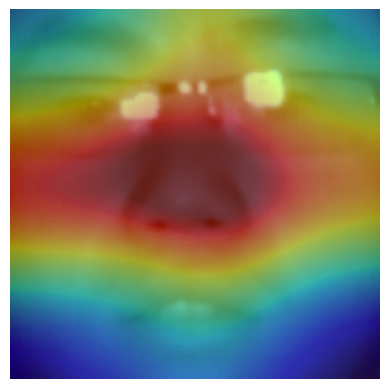

In [17]:
image_path = "combined_dataset\\combined_dataset\\10309\\01-B.bmp"  # Path to the NIR image
combined_image = preprocess_single_image(image_path)  # Generate 3-channel contrast image
input_tensor = preprocess_image_for_model(combined_image).to(device)  # Prepare for model input

# Apply Grad-CAM and display the result
heatmap = grad_cam(input_tensor)  # Generate Grad-CAM heatmap
overlay_heatmap(combined_image, heatmap)  # Overlay heatmap on the 3-channel contrast image

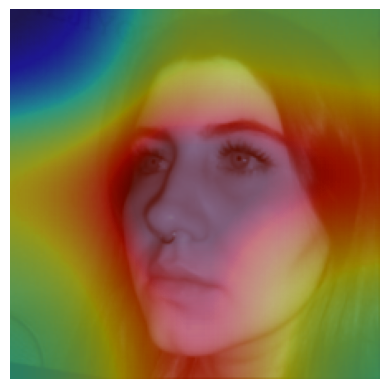

In [18]:
# %%
# Preprocess the input image
image_path = "LAMPHQ\\FP0131\\NIR_FP0131_1_RIGHT_a.jpg"  # Path to the NIR image
combined_image = preprocess_single_image(image_path)  # Generate 3-channel contrast image
input_tensor = preprocess_image_for_model(combined_image).to(device)  # Prepare for model input

# Apply Grad-CAM and display the result
heatmap = grad_cam(input_tensor)  # Generate Grad-CAM heatmap
overlay_heatmap(combined_image, heatmap)  # Overlay heatmap on the 3-channel contrast image


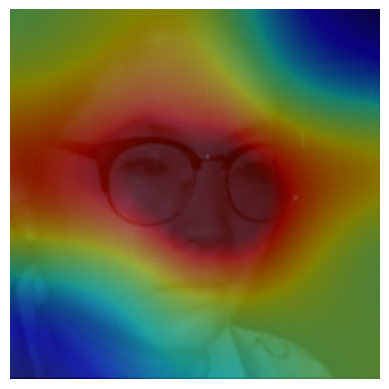

In [19]:
# Preprocess the input image
image_path = "LAMPHQ\\P0046\\NIR_P0046_1_LEFT_b.jpg"  # Path to the NIR image
combined_image = preprocess_single_image(image_path)  # Generate 3-channel contrast image
input_tensor = preprocess_image_for_model(combined_image).to(device)  # Prepare for model input

# Apply Grad-CAM and display the result
heatmap = grad_cam(input_tensor)  # Generate Grad-CAM heatmap
overlay_heatmap(combined_image, heatmap)  # Overlay heatmap on the 3-channel contrast image

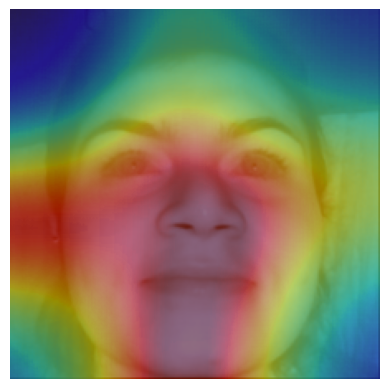

In [20]:
# Preprocess the input image
image_path = "LAMPHQ\\FP0140\\NIR_FP0140_1_DOWN_a.jpg"  # Path to the NIR image
combined_image = preprocess_single_image(image_path)  # Generate 3-channel contrast image
input_tensor = preprocess_image_for_model(combined_image).to(device)  # Prepare for model input

# Apply Grad-CAM and display the result
heatmap = grad_cam(input_tensor)  # Generate Grad-CAM heatmap
overlay_heatmap(combined_image, heatmap)  # Overlay heatmap on the 3-channel contrast image